In [36]:
from typing import Optional, Dict

# neural_transport
from neural_transport.models import MODELS
#from neural_transport.models.regulargrid import RegularGridModel
#from neural_transport.models.unet import UNet
from neural_transport.models.layers import (
    ACTIVATIONS,
    MultiScaleDecoder,
    MultiScaleEncoder,
)
from neural_transport.tools.conversion import *
from neural_transport.datasets.grids import (
    LATLON_PROTOTYPE_COORDS,
    VERTICAL_LAYERS_PROTOTYPE_COORDS,
)
from neural_transport.datamodule import CarbonDataModule

# plotting
import matplotlib.pyplot as plt
from matplotlib import cm

# torch
import pytorch_lightning as pl
import torch
import torch.nn as nn

# flow_matching
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.path import AffineProbPath
from flow_matching.solver import ODESolver


In [3]:
torch.set_float32_matmul_precision("high")
pl.seed_everything(42)

Seed set to 42


42

In [ ]:
# RegularGridModel

class RegularGridModel(nn.Module):

    def __init__(
        self,
        model_kwargs={},
        input_vars=[],
        target_vars=[],
        nlat=45,
        nlon=72,
        predict_delta=False,
        add_surfflux=False,
        massfixer=None,
        dt=3600,
        molecules=["co2"],
        targshift=False,
        vert_pos_embed=False,
        vert_pos_embed_kwargs=None,
        horizontal_interpolation=None,
        in_nlat=None,
        in_nlon=None,
        multiscale_kwargs=dict(in_chans=5, out_chans=128, layer_norm=True, act="swish"),
    ):
        super().__init__()

        self.nlat = nlat
        self.nlon = nlon
        self.input_vars = input_vars
        self.target_vars = target_vars

        self.in_nlat = in_nlat or nlat
        self.in_nlon = in_nlon or nlon
        self.horizontal_interpolation = horizontal_interpolation

        self.predict_delta = predict_delta
        self.add_surfflux = add_surfflux
        self.dt = dt
        self.massfixer = massfixer
        self.molecules = molecules
        self.targshift = targshift

        if self.horizontal_interpolation == "multiscale_encoder":
            self.multiscale_encoder = MultiScaleEncoder(
                in_shape=(self.in_nlat, self.in_nlon),
                out_shape=(self.nlat, self.nlon),
                **multiscale_kwargs,
            )
            self.multiscale_decoder = MultiScaleDecoder(
                in_shape=(self.in_nlat, self.in_nlon),
                out_shape=(self.nlat, self.nlon),
                **multiscale_kwargs,
            )

        self.init_model(**model_kwargs)

    def init_model(self, **model_kwargs):
        raise NotImplementedError

    def model(self):
        raise NotImplementedError

    def forward(self, batch):
        x_in = self.preprocess_inputs(batch)
        x_out = self.model(x_in)
        preds = self.postprocess_outputs(x_out, batch)
        return preds

    def normalize_batch(self, batch):
        batch_normalized = {}
        vars_to_normalize = self.input_vars
        
        for v in vars_to_normalize:
            print(f"input: {v}")
            if v not in batch:
                print(f"WARNING: skipping {v}, missing in batch")
                continue

            try:
                offset = batch[f"{v}_offset"]
                scale = batch[f"{v}_scale"]
            except KeyError as e:
                raise KeyError(
                    f"Missing offset/scale for input variable '{v}' during normalization: {e}."
                    f"Expected keys: {v}_offset, {v}_scale. "
                    f"Available keys: {list(batch.keys())}"
                )
            
            x_in_curr = (batch[v] - offset) / scale

            if self.targshift and (v in self.target_vars):
                batch_normalized[v] = x_in_curr - x_in_curr.mean((1, 2), keepdim=True)
            else:
                batch_normalized[v] = x_in_curr

        return batch_normalized

    def preprocess_inputs(self, batch):

        batch_normalized = self.normalize_batch(batch)

        x_in = torch.cat(list(batch_normalized.values()), dim=-1)

        B, N, C = x_in.shape

        x_in = x_in.reshape(B, self.in_nlat, self.in_nlon, C).permute(
            0, 3, 1, 2
        )  # b c h w

        if self.horizontal_interpolation == "multiscale_encoder":
            x_in = self.multiscale_encoder(x_in)

        elif self.horizontal_interpolation is not None:
            x_in = nn.functional.interpolate(
                x_in,
                size=(self.nlat, self.nlon),
                align_corners=True,
                mode=self.horizontal_interpolation,
            )

        # if not x_in.isfinite().all():
        #     print("x_in not finite", x_in.min(), x_in.mean(), x_in.max())

        return x_in
    
    def normalize_batch_target_vars(self, batch):
        
        batch_normalized = {}
        for v in self.target_vars:
            print(f"target: {v}")
            for suffix in ['', '_next']:
                key = f"{v}{suffix}"
                if key in batch:
                    mean = batch[f"{v}_offset"]
                    std = batch[f"{v}_scale"]
                    x_in_curr = (batch[key] - mean) / std
                if self.targshift:
                    batch_normalized[key] = x_in_curr - x_in_curr.mean((1, 2), keepdim=True)
                else:
                    batch_normalized[key] = x_in_curr

        return batch_normalized
    
    def postprocess_outputs(self, x_out, batch):

        B, N, _ = batch[self.target_vars[0]].shape

        if self.horizontal_interpolation == "multiscale_encoder":
            x_out = self.multiscale_decoder(x_out)
        elif self.horizontal_interpolation is not None:
            x_out = nn.functional.interpolate(
                x_out,
                size=(self.in_nlat, self.in_nlon),
                align_corners=True,
                mode=self.horizontal_interpolation,
            )

        x_out = x_out.permute(0, 2, 3, 1).reshape(B, N, -1)
        
        x_grid_offset = torch.cat(
            [(batch[f"{v}_offset"]).expand_as(batch[v]) for v in self.target_vars],
            dim=-1,
        )
        x_grid_scale = torch.cat(
            [(batch[f"{v}_scale"]).expand_as(batch[v]) for v in self.target_vars],
            dim=-1,
        )

        x_out_prev = torch.cat(
            [batch[v] for v in self.target_vars],
            dim=-1,
        )
        
        x_grid_delta_offset = torch.cat(
            [
                (batch[f"{v}_delta_offset"]).expand_as(batch[v])
                for v in self.target_vars
            ],
            dim=-1,
        )
        x_grid_delta_scale = torch.cat(
            [(batch[f"{v}_delta_scale"]).expand_as(batch[v]) for v in self.target_vars],
            dim=-1,
        )

        # if not x_out.isfinite().all():
        #     print("x_out not finite", x_out.min(), x_out.mean(), x_out.max())

        if self.predict_delta:
            x_out_resc = x_out * x_grid_delta_scale + x_grid_delta_offset

            x_out_next = x_out_prev + x_out_resc
        else:
            x_out_next = x_out * x_grid_scale + x_grid_offset

        # if not x_out_next.isfinite().all():
        #     print(
        #         "x_out_next not finite",
        #         x_out_next.min(),
        #         x_out_next.mean(),
        #         x_out_next.max(),
        #     )

        preds = {}
        i = 0
        for v in self.target_vars:
            C = batch[v].shape[-1]
            preds[v] = x_out_next[..., i : i + C]
            i += C
        
        for molecule in self.molecules:

            # mass_pred_pre_fixer = (
            #     (preds[f"{molecule}massmix"] / 1e6) * batch["airmass_next"]
            # ).sum((1, 2), keepdim=True)

            if self.massfixer and (not self.training):

                mass_pred = (preds[f"{molecule}massmix"]) * batch["airmass_next"]

                mass_old = (batch[f"{molecule}massmix"]) * batch["airmass"]
                if not self.add_surfflux:
                    surfflux_as_masssource = (
                        (
                            batch[f"{molecule}flux_land"]
                            + batch[f"{molecule}flux_ocean"]
                            + batch[f"{molecule}flux_anthro"]
                        )
                        * batch["cell_area"]
                        * self.dt
                        / 1e6  # / 1e12  # PgCO2
                    )
                    B, N, C = mass_old.shape
                    mass_old = mass_old + (
                        surfflux_as_masssource.sum((1, 2), keepdim=True) / (N * C)
                    )
                if self.massfixer == "shift":

                    preds[f"{molecule}massmix"] = (
                        (
                            mass_pred
                            - mass_pred.mean((1, 2), keepdim=True)
                            + mass_old.mean((1, 2), keepdim=True)
                        )
                    ) / batch["airmass_next"]

                elif self.massfixer == "scale":

                    preds[f"{molecule}massmix"] = (
                        (
                            mass_pred
                            * mass_old.mean((1, 2), keepdim=True)
                            / mass_pred.mean((1, 2), keepdim=True)
                        )
                    ) / batch["airmass_next"]

            # mass_pred_after_fixer = (
            #     (preds[f"{molecule}massmix"] / 1e6) * batch["airmass_next"]
            # ).sum((1, 2), keepdim=True)

            if self.add_surfflux:

                surfflux_as_massmixsource_prev = (
                    (
                        batch[f"{molecule}flux_land"]
                        + batch[f"{molecule}flux_ocean"]
                        + batch[f"{molecule}flux_anthro"]
                    )
                    * batch["cell_area"]
                    * self.dt
                    / 1e6  # / 1e12  # PgCO2
                ) / batch["airmass_next"][
                    ..., :1
                ]  # * 1e6

                preds[f"{molecule}massmix"][..., :1] = (
                    preds[f"{molecule}massmix"][..., :1]
                    + surfflux_as_massmixsource_prev
                )

            ### NOTE: Roughly 0.5% Mass Error remains !!!
            ### THIS IS IN THE DATA ALREADY :/ don't know why.

            # virtual_pred = batch[f"{molecule}massmix"].clone()
            # virtual_pred = virtual_pred * batch["airmass"] / batch["airmass_next"]
            # virtual_pred[..., :1] = (
            #     virtual_pred[..., :1] + surfflux_as_massmixsource_prev
            # )

            # mass_pred = (
            #     (preds[f"{molecule}massmix"] / 1e6) * batch["airmass_next"]
            # ).sum((1, 2), keepdim=True)
            # mass_virtual = ((virtual_pred / 1e6) * batch["airmass_next"]).sum(
            #     (1, 2), keepdim=True
            # )
            # mass_targ = (
            #     (batch[f"{molecule}massmix_next"] / 1e6) * batch["airmass_next"]
            # ).sum((1, 2), keepdim=True)
            # mass_old = ((batch[f"{molecule}massmix"] / 1e6) * batch["airmass"]).sum(
            #     (1, 2), keepdim=True
            # )

            # rmse_mass = ((mass_targ - mass_pred) ** 2).mean() ** 0.5
            # rmse_pre = ((mass_targ - mass_pred_pre_fixer) ** 2).mean() ** 0.5
            # rmse_zero = ((mass_old - mass_pred_after_fixer) ** 2).mean() ** 0.5
            # rmse_post = ((mass_targ - mass_pred_after_fixer) ** 2).mean() ** 0.5
            # rmse_virtual = ((mass_targ - mass_virtual) ** 2).mean() ** 0.5

            # rmse_delta = ((mass_targ - mass_old) ** 2).mean() ** 0.5

            # print(
            #     f"RMSE in {molecule} mass: {rmse_mass:.5f}, RMSE Delta: {rmse_delta:.5f}, RMSE PreFixer: {rmse_pre:.5f}, RMSE PostFixer: {rmse_post:.5f}, RMSE Virtual {rmse_virtual:.5f}, RMSE Zero {rmse_zero:.5f}"
            # )
            # breakpoint()

        return preds


In [5]:
# UNet

def get_norm(norm, n_in, n_groups=8):

    if norm == "batch":
        return nn.BatchNorm2d(n_in)
    elif norm == "group":
        return nn.GroupNorm(n_groups, n_in)
    elif norm == "instance":
        return nn.InstanceNorm2d(n_in, affine=True)
    else:
        return nn.Identity()


class PeriodicPadding(nn.Module):

    def __init__(self, n_pad):
        super().__init__()
        self.n_pad = n_pad

    def forward(self, x):

        x = nn.functional.pad(
            x, (self.n_pad, self.n_pad, 0, 0), mode="circular"
        )  # torch.cat([x[:, :, -self.n_pad:, :], x, x[:, :, :self.n_pad, :]], dim = 2)

        x = nn.functional.pad(
            x, (0, 0, self.n_pad, self.n_pad), mode="constant", value=0
        )

        return x
# J: Basically mimicks that the earth is a cylinder.
# J: But is x not just replaced instead of added?

class ResBlock(nn.Module):

    def __init__(
        self,
        n_in,
        embed_dim,
        act="leakyrelu",
        norm="batch",
        filter_size=3,
        add_skip=True,
    ):
        super().__init__()

        n_pad = (filter_size - 1) // 2

        self.pad = PeriodicPadding(n_pad)

        self.conv = nn.Conv2d(
            n_in, embed_dim, filter_size, stride=1, padding=0, bias=(norm is None)
        )

        self.act = ACTIVATIONS[act]()

        self.norm = get_norm(norm, embed_dim)
        self.add_skip = add_skip

    def forward(self, x):

        skip = x

        x = self.pad(x)
        x = self.conv(x)
        x = self.act(x)
        x = self.norm(x)

        if self.add_skip and (skip.shape == x.shape):
            x = x + skip

        return x


class UNet(RegularGridModel):

    def init_model(
        self,
        in_chans=193,
        out_chans=19,
        embed_dim=128,
        act="leakyrelu",
        norm="batch",
        enc_filters=[[7], [3, 3], [3, 3], [3, 3]],
        dec_filters=[[3, 3], [3, 3], [3, 3], [3, 3]],
        in_interpolation="bilinear",
        out_interpolation="nearest-exact",
        readout_act="none",
        mlp_as_readout=False,
        out_clip=None,
    ):

        self.in_chans = in_chans
        self.out_chans = out_chans
        self.in_interpolation = in_interpolation
        self.out_interpolation = out_interpolation
        self.out_clip = out_clip

        depth = len(enc_filters)
        assert depth == len(dec_filters)

        self.resc_lat = ((self.nlat // (2**depth)) + 1) * (2**depth)
        self.resc_lon = ((self.nlon // (2**depth)) + 1) * (2**depth)

        self.embed_dim = embed_dim

        enc_stages = []
        for i, filters in enumerate(enc_filters):
            enc_stage = []
            if i > 0:
                enc_stage.append(nn.MaxPool2d(2, 2))
            for j, filter_size in enumerate(filters):
                n_in = in_chans if (i == 0) and (j == 0) else embed_dim
                enc_stage.append(
                    ResBlock(
                        n_in, embed_dim, act=act, norm=norm, filter_size=filter_size
                    )
                )
            enc_stages.append(nn.Sequential(*enc_stage))

        self.enc_stages = nn.ModuleList(enc_stages)

        dec_stages = []
        for i, filters in enumerate(dec_filters):
            dec_stage = []
            for j, filter_size in enumerate(filters):
                dec_stage.append(
                    ResBlock(
                        embed_dim,
                        embed_dim,
                        act=act,
                        norm=norm,
                        filter_size=filter_size,
                    )
                )

            if i != (len(dec_filters) - 1):
                dec_stage.append(nn.Upsample(scale_factor=2))
            dec_stages.append(nn.Sequential(*dec_stage))

        self.dec_stages = nn.ModuleList(dec_stages)

        if not mlp_as_readout:
            self.readout = ResBlock(
                embed_dim,
                out_chans,
                act=readout_act,
                norm="none",
                filter_size=1,
                add_skip=True,
            )
        else:

            final_linear = nn.Conv2d(embed_dim, out_chans, 1, bias=True)
            nn.init.zeros_(final_linear.weight)
            nn.init.zeros_(final_linear.bias)
            self.readout = nn.Sequential(
                nn.Conv2d(embed_dim, embed_dim, 1, bias=False),
                ACTIVATIONS[act](),
                get_norm(norm, embed_dim),
                final_linear,
            )

            # def init_weights(m):
            #     if isinstance(m, (nn.Conv2d,)):
            #         nn.init.kaiming_normal_(m.weight)
            #     elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm, nn.InstanceNorm2d)):
            #         nn.init.ones_(m.weight)

            #     if hasattr(m, "bias") and m.bias is not None:
            #         nn.init.zeros_(m.bias)

            # self.apply(init_weights)

    def model(self, x_in):

        x = nn.functional.interpolate(
            x_in,
            size=(self.resc_lat, self.resc_lon),
            align_corners=True,
            mode=self.in_interpolation,
        )

        skips = []
        for stage in self.enc_stages:
            x = stage(x)
            skips.append(x)

        x = self.dec_stages[0](x)

        for stage, skip in zip(self.dec_stages[1:], skips[::-1][1:]):
            x = stage(x + skip)

        x = nn.functional.interpolate(
            x, size=(self.nlat, self.nlon), mode=self.out_interpolation
        )

        x_out = self.readout(x)

        if self.out_clip:
            x_out = x_out.clamp(-self.out_clip, self.out_clip)

        return x_out


In [6]:
# train UNet parameters 1/2

TARGET_VARS = ["co2massmix"]
FORCING_VARS_1D = [
    # "flow_time"
]

# Uncomment for conditional Flow Matching
FORCING_VARS_2D = [
    # "blh",
    # "cell_area",
    # "co2flux_anthro",
    # "co2flux_land",
    # "co2flux_ocean",
    # "orography",
    # "tisr",
]
FORCING_VARS_3D = [
    # "airmass",
    # "gph_bottom",
    # "gph_top",
    # "p_bottom",
    # "p_top",
    # "q",
    # "t",
    # "u",
    # "v",
]
grid = "latlon5.625"
vertical_levels = "l10"
freq = "6h"

nlev = len(VERTICAL_LAYERS_PROTOTYPE_COORDS[vertical_levels]["level"])

FORCING_VARS = FORCING_VARS_1D + FORCING_VARS_2D + FORCING_VARS_3D
LEN_ALL_TARGET_VARS = nlev * len(TARGET_VARS)
LEN_ALL_FORCING_VARS = len(FORCING_VARS_1D) + len(FORCING_VARS_2D) + nlev * len(FORCING_VARS_3D)
LEN_ALL_VARS = LEN_ALL_TARGET_VARS + LEN_ALL_FORCING_VARS

lat = LATLON_PROTOTYPE_COORDS[grid]["lat"]
lon = LATLON_PROTOTYPE_COORDS[grid]["lon"]

MODEL_DIMS = {
    "XS": dict(embed_dim=64),
    "S": dict(embed_dim=128),
    "M": dict(embed_dim=256),
    "L": dict(embed_dim=512),
    "XL": dict(embed_dim=1024),
}

MODEL_SIZE = "S"

model_kwargs = dict(
    model_kwargs=dict(
        in_chans=LEN_ALL_VARS,
        out_chans=LEN_ALL_TARGET_VARS,
        embed_dim=MODEL_DIMS[MODEL_SIZE]["embed_dim"],
        act="leakyrelu",
        norm="batch",
        enc_filters=[[7], [3, 3], [3, 3], [3, 3]],
        dec_filters=[[3, 3], [3, 3], [3, 3], [3, 3]],
        in_interpolation="bilinear",
        out_interpolation="nearest-exact",
        out_clip=None,
    ),
    input_vars=TARGET_VARS + FORCING_VARS,
    target_vars=TARGET_VARS,
    nlat=len(lat),
    nlon=len(lon),
    predict_delta=True,
    add_surfflux=True,
    dt=60 * 60 * 6,
    massfixer="scale",
    targshift=True,
    # time_embedding=False
)

In [7]:
print(f"vertical layers prototype coords: {nlev}")
print(f"Lenth of 1D forcing variables: {len(FORCING_VARS_1D)}")
print(f"Lenght of 2D forcing variables: {len(FORCING_VARS_2D)}")
print(f"Length of 3D forcing variables: {len(FORCING_VARS_3D)}")
print(f"Length of all forcing variables: {len(FORCING_VARS_1D)} + {len(FORCING_VARS_2D)} + {nlev} * {len(FORCING_VARS_3D)} = {LEN_ALL_FORCING_VARS}")
print(f"Length of all target variables: {LEN_ALL_TARGET_VARS}")
print(f"Length of all variables: {LEN_ALL_VARS}")

vertical layers prototype coords: 10
Lenth of 1D forcing variables: 0
Lenght of 2D forcing variables: 0
Length of 3D forcing variables: 0
Length of all forcing variables: 0 + 0 + 10 * 0 = 0
Length of all target variables: 10
Length of all variables: 10


In [8]:
# train UNet parameters 2/2

N_GPUS = 1
BATCH_SIZE_TRAIN = 64
BATCH_SIZE_PRED = 32

grid = "latlon5.625"
vertical_levels = "l10"
freq = "6h"

data_kwargs = dict(
    data_path="/Net/Groups/BGI/tscratch/vbenson/graph_tm/data/Carbontracker",
    dataset="carbontracker",
    grid=grid,
    vertical_levels=vertical_levels,
    freq=freq,
    n_timesteps=1,
    batch_size_train=BATCH_SIZE_TRAIN // N_GPUS,
    batch_size_pred=BATCH_SIZE_PRED,
    num_workers=32 * N_GPUS,
    val_rollout_n_timesteps=31,
    target_vars=["co2massmix", "airmass"],
    forcing_vars=[
        "gph_bottom",
        "gph_top",
        "p_bottom",
        "p_top",
        "q",
        "t",
        "u",
        "v",
        "blh",
        "cell_area",
        "co2flux_anthro",
        "co2flux_land",
        "co2flux_ocean",
        "orography",
        "tisr",
    ],
    compute=False,
    # time_interval=["1990-01-01", "2014-12-31"],
)

In [9]:
# instantiate UNet model

model = UNet(**model_kwargs)

# mimick FlowMatching

class Cheating:
    def __init__(self):
        pass
self = Cheating()
self.model = model

In [10]:
dset = CarbonDataModule(**data_kwargs)
dset

In [11]:
dir(dset)

['CHECKPOINT_HYPER_PARAMS_KEY',
 'CHECKPOINT_HYPER_PARAMS_NAME',
 'CHECKPOINT_HYPER_PARAMS_TYPE',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__jit_unused_properties__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_log_hyperparams',
 '_set_hparams',
 '_to_hparams_dict',
 'allow_zero_length_dataloader_with_multiple_devices',
 'batch_size_pred',
 'batch_size_train',
 'compute',
 'data_path',
 'dataset',
 'forcing_vars',
 'freq',
 'from_datasets',
 'get_dataloader',
 'grid',
 'hparams',
 'hparams_initial',
 'load_from_checkpoint',
 'load_state_dict',
 'n_timesteps',
 'name',
 'num_workers',
 'on_after_batch_transfer',
 'on_before_batch_transfer',
 'on_exception',
 'predic

In [12]:
dset.setup('fit')

In [13]:
dir(dset)

['CHECKPOINT_HYPER_PARAMS_KEY',
 'CHECKPOINT_HYPER_PARAMS_NAME',
 'CHECKPOINT_HYPER_PARAMS_TYPE',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__jit_unused_properties__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_log_hyperparams',
 '_set_hparams',
 '_to_hparams_dict',
 'allow_zero_length_dataloader_with_multiple_devices',
 'batch_size_pred',
 'batch_size_train',
 'compute',
 'data_path',
 'dataset',
 'forcing_vars',
 'freq',
 'from_datasets',
 'get_dataloader',
 'grid',
 'hparams',
 'hparams_initial',
 'load_from_checkpoint',
 'load_state_dict',
 'n_timesteps',
 'name',
 'num_workers',
 'on_after_batch_transfer',
 'on_before_batch_transfer',
 'on_exception',
 'predic

In [14]:
dset.val_dataset

In [15]:
dl = dset.train_dataloader()
dl

In [16]:
batch = next(iter(dl))
batch = {k: v[:, 0,...] if isinstance(v, torch.Tensor) else v for k, v in batch.items() }
batch

{'airmass': tensor([[[ 1.0679,  1.3018,  2.8871,  ..., 27.5659, 30.1167, 14.3068],
          [ 1.0621,  1.2932,  2.8647,  ..., 27.4286, 30.0794, 14.3068],
          [ 1.0572,  1.2859,  2.8457,  ..., 27.3119, 30.0477, 14.3068],
          ...,
          [ 1.5487,  2.0164,  4.7471,  ..., 38.9914, 33.2224, 14.3068],
          [ 1.5491,  2.0168,  4.7483,  ..., 38.9988, 33.2244, 14.3068],
          [ 1.5477,  2.0149,  4.7432,  ..., 38.9674, 33.2158, 14.3068]],
 
         [[ 1.0564,  1.2848,  2.8427,  ..., 27.2931, 30.0426, 14.3068],
          [ 1.0509,  1.2766,  2.8213,  ..., 27.1620, 30.0070, 14.3068],
          [ 1.0464,  1.2699,  2.8040,  ..., 27.0553, 29.9780, 14.3068],
          ...,
          [ 1.5585,  2.0309,  4.7849,  ..., 39.2233, 33.2854, 14.3068],
          [ 1.5585,  2.0308,  4.7848,  ..., 39.2230, 33.2853, 14.3068],
          [ 1.5568,  2.0283,  4.7781,  ..., 39.1817, 33.2741, 14.3068]],
 
         [[ 1.0767,  1.3148,  2.9210,  ..., 27.7744, 30.1734, 14.3068],
          [ 1.071

In [17]:
batch.keys()

dict_keys(['airmass', 'airmass_delta_offset', 'airmass_delta_scale', 'airmass_next', 'airmass_next_offset', 'airmass_next_scale', 'airmass_offset', 'airmass_scale', 'blh', 'blh_delta_offset', 'blh_delta_scale', 'blh_next_offset', 'blh_next_scale', 'blh_offset', 'blh_scale', 'cell_area', 'cell_area_delta_offset', 'cell_area_delta_scale', 'cell_area_next_offset', 'cell_area_next_scale', 'cell_area_offset', 'cell_area_scale', 'co2flux_anthro', 'co2flux_anthro_delta_offset', 'co2flux_anthro_delta_scale', 'co2flux_anthro_next_offset', 'co2flux_anthro_next_scale', 'co2flux_anthro_offset', 'co2flux_anthro_scale', 'co2flux_land', 'co2flux_land_delta_offset', 'co2flux_land_delta_scale', 'co2flux_land_next_offset', 'co2flux_land_next_scale', 'co2flux_land_offset', 'co2flux_land_scale', 'co2flux_ocean', 'co2flux_ocean_delta_offset', 'co2flux_ocean_delta_scale', 'co2flux_ocean_next_offset', 'co2flux_ocean_next_scale', 'co2flux_ocean_offset', 'co2flux_ocean_scale', 'co2massmix', 'co2massmix_delta_o

In [18]:
batch['co2massmix'].shape

torch.Size([64, 2048, 10])

In [19]:
x_1 = batch[f"{self.model.target_vars[0]}_next"]
x_1.shape

torch.Size([64, 2048, 10])

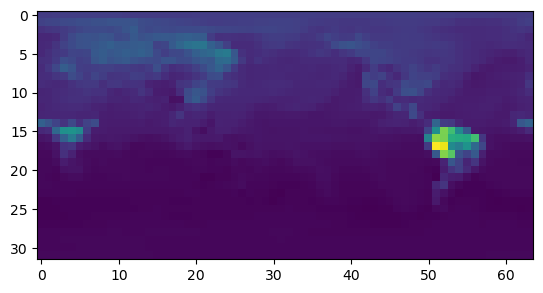

In [20]:
plt.imshow(x_1[0,:,0].reshape(32, 64).numpy()[::-1])

In [21]:
min_val = x_1.min()
max_val = x_1.max()

print(min_val, max_val)

tensor(505.0536) tensor(778.5994)


target: co2massmix
tensor(-5.9038) tensor(13.1214)
['co2massmix']
dict_keys(['co2massmix', 'co2massmix_next'])


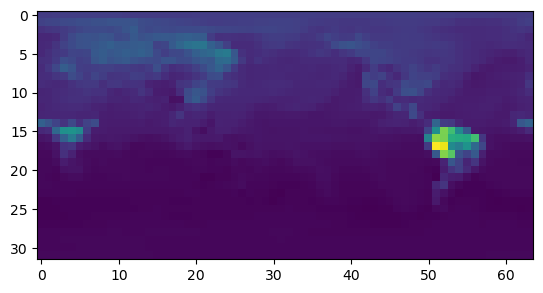

In [22]:
batch_normalized = self.model.normalize_batch_target_vars(batch)
x_1_normalized = batch_normalized[f"{self.model.target_vars[0]}_next"]
min_normalized = x_1_normalized.min()
max_normalized = x_1_normalized.max()

print(min_normalized, max_normalized)
print(self.model.target_vars)
print(batch_normalized.keys())

plt.imshow(x_1_normalized[0,:,0].reshape(32, 64).numpy()[::-1])


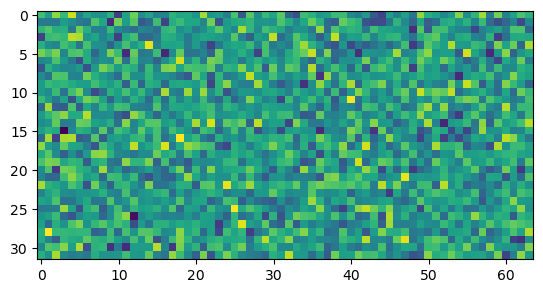

In [23]:
x_0 = torch.randn_like(x_1, device=x_1.device)
plt.imshow(x_0[0,:,0].reshape(32, 64).numpy()[::-1])

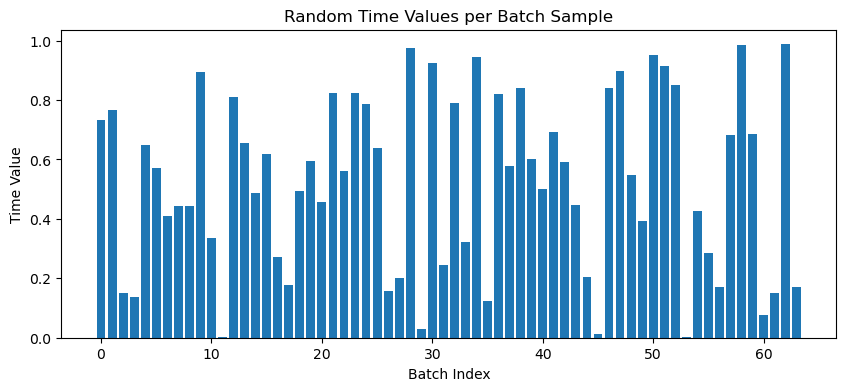

In [24]:
t = torch.rand(x_1.shape[0], device=x_1.device)
plt.figure(figsize=(10, 4))
plt.bar(range(len(t)), t.cpu().numpy())
plt.xlabel('Batch Index')
plt.ylabel('Time Value')
plt.title('Random Time Values per Batch Sample')
plt.show()

In [25]:
path = AffineProbPath(scheduler=CondOTScheduler())
path_sample = path.sample(
            t=t,
            x_0=x_0,
            x_1=x_1_normalized
        )

In [26]:
batch_pred = batch.copy()
batch_pred[self.model.target_vars[0]] = path_sample.x_t + x_0

preds = self.model(batch_pred)

input: co2massmix
pp batch keys: dict_keys(['airmass', 'airmass_delta_offset', 'airmass_delta_scale', 'airmass_next', 'airmass_next_offset', 'airmass_next_scale', 'airmass_offset', 'airmass_scale', 'blh', 'blh_delta_offset', 'blh_delta_scale', 'blh_next_offset', 'blh_next_scale', 'blh_offset', 'blh_scale', 'cell_area', 'cell_area_delta_offset', 'cell_area_delta_scale', 'cell_area_next_offset', 'cell_area_next_scale', 'cell_area_offset', 'cell_area_scale', 'co2flux_anthro', 'co2flux_anthro_delta_offset', 'co2flux_anthro_delta_scale', 'co2flux_anthro_next_offset', 'co2flux_anthro_next_scale', 'co2flux_anthro_offset', 'co2flux_anthro_scale', 'co2flux_land', 'co2flux_land_delta_offset', 'co2flux_land_delta_scale', 'co2flux_land_next_offset', 'co2flux_land_next_scale', 'co2flux_land_offset', 'co2flux_land_scale', 'co2flux_ocean', 'co2flux_ocean_delta_offset', 'co2flux_ocean_delta_scale', 'co2flux_ocean_next_offset', 'co2flux_ocean_next_scale', 'co2flux_ocean_offset', 'co2flux_ocean_scale', 

In [27]:
var = self.model.target_vars[0]
x_pred = preds[var]

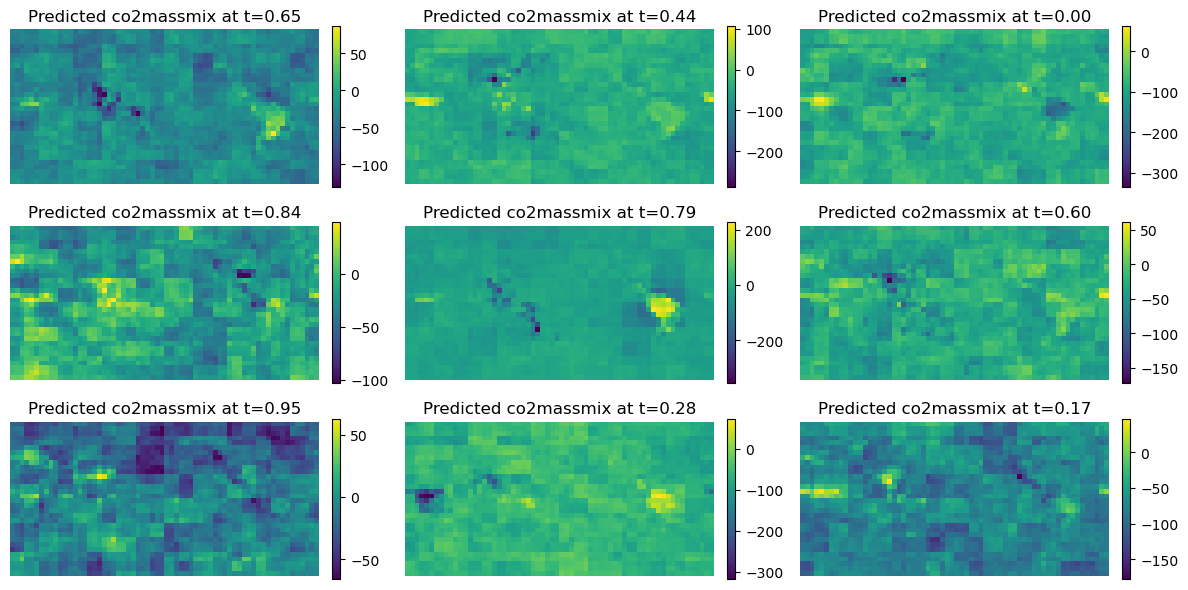

In [28]:
choose = [4, 7, 11, 38, 32, 39, 50, 55, 56]

fig, axes = plt.subplots(3, 3, figsize=(12, 6))

for i in range(3):
    for j in range(3):
        ax = axes[i,j]
        batch_index = choose[j + i*3]
        im = ax.imshow(x_pred[batch_index,:,0].reshape(32, 64).detach().numpy()[::-1])
        ax.set_title(f"Predicted {var} at t={t[batch_index].item():.2f}")
        ax.axis('off')
        fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


Should this not show for $t$ close to $0$ just pure noise and for $t$ close to $1$ some identifiable world map?

In [ ]:
class VelocityWrapper(nn.Module):
    def __init__(
        self,
        model: nn.Module,
        target_vars: str,
        offset: Optional[torch.Tensor] = None,
        scale: Optional[torch.Tensor] = None,
        delta_offset: Optional[torch.Tensor] = None,
        delta_scale: Optional[torch.Tensor] = None,
        static_batch: Optional[Dict[str, torch.Tensor]] = None,
    ):
        super().__init__()
        self.model = model
        self.target_vars = target_vars

        self.offset = offset
        self.scale = scale
        self.delta_offset = delta_offset
        self.delta_scale = delta_scale

        self.static_batch = static_batch or {}

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        batch_vf = {
            self.target_vars: x,
            "flow_time": t,
            f"{self.target_vars}_offset": self.offset,
            f"{self.target_vars}_scale": self.scale,
            f"{self.target_vars}_delta_offset": self.delta_offset,
            f"{self.target_vars}_delta_scale": self.delta_scale,
        }

        batch_vf.update(self.static_batch)
        out = self.model(batch_vf)
        return out[self.target_vars]

In [ ]:
class FlowMatching(nn.Module):
    def __init__(
            self,
            model="unet",
            # model_kwargs={},
            return_intermediates=False,
            method='midpoint',
            step_size=0.01
            ):
        super().__init__()
        ## alter input variables to always contain x_t and t
        self.model = model # MODELS[model](**model_kwargs)
        self.return_intermediates = return_intermediates
        self.method = method
        self.step_size = step_size
        self.path = AffineProbPath(scheduler=CondOTScheduler())
        self.target_vars = self.model.target_vars[0] ### Here target_vars[0] is supposed to be 'co2massmix'
        self.velocity_model = VelocityWrapper(self.model, self.target_vars)
        self.solver = ODESolver(velocity_model=self.velocity_model)


    def forward(self, batch):
        if self.training:
            return self.training_forward(batch)
        else:
            return self.inference_forward(batch)


    def training_forward(self, batch):
        # extract target_vars to get x1 and normalize # B N C
        x_1 = batch[f"{self.target_vars}_next"]
        batch_normalized = self.model.normalize_batch_target_vars(batch)
        x_1_normalized = batch_normalized[f"{self.target_vars}_next"]

        # sample noise [B N C]
        x_0 = torch.randn_like(x_1, device=x_1.device)

        # sample time [B]
        t = torch.rand(x_1.shape[0], device=x_1.device)
        batch["flow_time"] = t
        ### add offset and scale to batch for normalization

        # sample path
        path_sample = self.path.sample(
            t=t,
            x_0=x_0,
            x_1=x_1_normalized
        )

        # compute flow matching loss and add denormalized x_1
        batch_pred = batch.copy()
        batch_pred[self.target_vars] = path_sample.x_t + x_0
        ### add offset and scale to batch for normalization
        ### not overrideing but x_t

        # (path_sample.x_t + - dt_sigma * x_0) / dt_alpha
        ### How to obtain dt_sigma and dt_alpha from the path?
        preds = self.model(batch_pred)
        # preds = self.model(path_sample.x_t, path_sample.t) + x_1
        ### UNet does not take t as input yet

        return preds # B N C

    def set_velocity_stats(self, offset, scale, delta_offset, delta_scale, batch):
        static_batch = batch
        # for v in self.model.input_vars:
        #     print(f"input_vars: {v}")
        #     if v not in self.target_vars:
        #         static_batch[v] = batch[v]        
        self.velocity_model = VelocityWrapper(
            self.model,
            self.target_vars,
            offset=offset, scale=scale,
            delta_offset=delta_offset, delta_scale=delta_scale,
            static_batch=static_batch
        )
        self.solver.velocity_model = self.velocity_model


    def inference_forward(self, batch):
        # sample noise to get x0 # B N C
        
         # B N C
        x_init = torch.randn(*all_levels.shape, device=batch[self.target_vars].device)
        #surface_level = batch[self.target_vars][:,:,0:1] # B N 1
        #x_init = torch.randn(*surface_level.shape, device=batch[self.target_vars].device)

        # get timesteps for integration T
        time_grid = torch.linspace(0, 1, steps=10, device=x_init.device)

        # UNet expects normalization parameters
        self.set_velocity_stats(
            batch[f"{self.target_vars}_offset"],
            batch[f"{self.target_vars}_scale"],
            batch[f"{self.target_vars}_delta_offset"],
            batch[f"{self.target_vars}_delta_scale"],
            batch
        )

        # solve the ODE to get the trajectory
        sol = self.solver.sample(time_grid=time_grid,
                                 x_init=x_init, method=self.method,
                                 step_size=self.step_size,
                                 return_intermediates=self.return_intermediates
                                )
        # denormalize sol
        return sol
    
    #def inference_obs_forward(self, batch):
    #    return sol

In [33]:
flow = FlowMatching(
    model=model,
    return_intermediates=True,
    method='midpoint',
    step_size=0.01,
)

In [34]:
flow.train()
preds_flow = flow(batch)

target: co2massmix
input: co2massmix
pp batch keys: dict_keys(['airmass', 'airmass_delta_offset', 'airmass_delta_scale', 'airmass_next', 'airmass_next_offset', 'airmass_next_scale', 'airmass_offset', 'airmass_scale', 'blh', 'blh_delta_offset', 'blh_delta_scale', 'blh_next_offset', 'blh_next_scale', 'blh_offset', 'blh_scale', 'cell_area', 'cell_area_delta_offset', 'cell_area_delta_scale', 'cell_area_next_offset', 'cell_area_next_scale', 'cell_area_offset', 'cell_area_scale', 'co2flux_anthro', 'co2flux_anthro_delta_offset', 'co2flux_anthro_delta_scale', 'co2flux_anthro_next_offset', 'co2flux_anthro_next_scale', 'co2flux_anthro_offset', 'co2flux_anthro_scale', 'co2flux_land', 'co2flux_land_delta_offset', 'co2flux_land_delta_scale', 'co2flux_land_next_offset', 'co2flux_land_next_scale', 'co2flux_land_offset', 'co2flux_land_scale', 'co2flux_ocean', 'co2flux_ocean_delta_offset', 'co2flux_ocean_delta_scale', 'co2flux_ocean_next_offset', 'co2flux_ocean_next_scale', 'co2flux_ocean_offset', 'co2

In [35]:
flow.eval()
with torch.no_grad():
    sol = flow(batch)

static_batch keys: ['airmass', 'airmass_delta_offset', 'airmass_delta_scale', 'airmass_next', 'airmass_next_offset', 'airmass_next_scale', 'airmass_offset', 'airmass_scale', 'blh', 'blh_delta_offset', 'blh_delta_scale', 'blh_next_offset', 'blh_next_scale', 'blh_offset', 'blh_scale', 'cell_area', 'cell_area_delta_offset', 'cell_area_delta_scale', 'cell_area_next_offset', 'cell_area_next_scale', 'cell_area_offset', 'cell_area_scale', 'co2flux_anthro', 'co2flux_anthro_delta_offset', 'co2flux_anthro_delta_scale', 'co2flux_anthro_next_offset', 'co2flux_anthro_next_scale', 'co2flux_anthro_offset', 'co2flux_anthro_scale', 'co2flux_land', 'co2flux_land_delta_offset', 'co2flux_land_delta_scale', 'co2flux_land_next_offset', 'co2flux_land_next_scale', 'co2flux_land_offset', 'co2flux_land_scale', 'co2flux_ocean', 'co2flux_ocean_delta_offset', 'co2flux_ocean_delta_scale', 'co2flux_ocean_next_offset', 'co2flux_ocean_next_scale', 'co2flux_ocean_offset', 'co2flux_ocean_scale', 'co2massmix', 'co2massmi

In [ ]:
# anpassen von variables -> offset/scale/delta is loaded, even if not given into the model!?
# neural_transport -> datamolude.py -> CarbonDataset -> def __getitem__(self, t: int): ->
# data |= {
#             f"{k}_offset": torch.from_numpy(
#                 self.expand_dims(self.stats_ds[k].sel(stats="mean")).values.astype(
#                     "float32"
#                 )
#             )
#             for k in self.stats_ds.data_vars.keys()  !!!!!! instead of e.g. self.vars
#         }
# same for scale

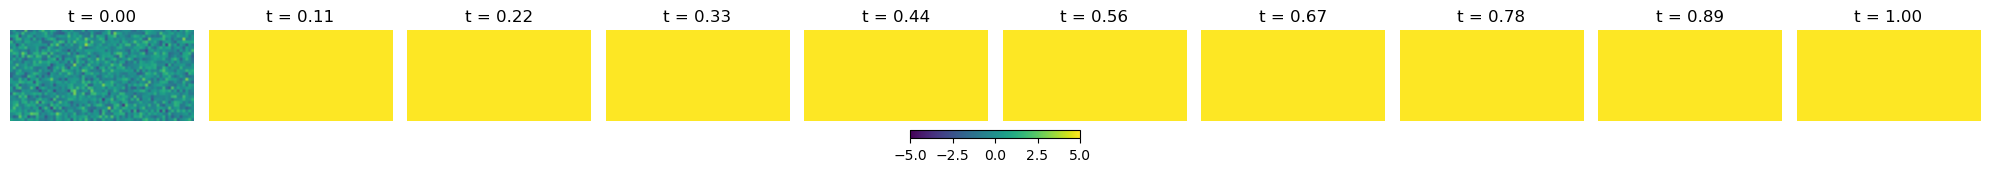

In [59]:
# sol.shape: (T=10, B=64, N=2048, C=10) -> one batch (B=0), surface level (C=0)
sol_surface = sol[:, 0, :, 0]  # shape: [T, N]

# reshape to 2D grid (assuming [lat=32, lon=64])
lat, lon = 32, 64
sol_surface_2d = sol_surface.reshape((10, lat, lon))  # shape: [T, lat, lon]

# plot
fig, axs = plt.subplots(1, 10, figsize=(20, 2))

vmin, vmax = -5, 5
for i in range(10):
    im = axs[i].imshow(sol_surface_2d[i], cmap="viridis", vmin=vmin, vmax=vmax)
    axs[i].set_title(f"t = {i/9:.2f}")
    axs[i].axis("off")

plt.tight_layout()
plt.colorbar(im, ax=axs, orientation='horizontal', fraction=0.05, pad=0.05)
plt.show()

Haha, seem's like it works not at all